# Karan Bedi - Prodigal AI Assignment
## Task 3 - Multi-Objective AI Assistant


## Importing Libraries

These libraries support local inference, structured parsing, metric calculation, and visualisation. The task has multiple outputs per review, so the evaluation needs to track both classification accuracy and response quality.


In [1]:
import json
import os
import re
import time
from datetime import datetime
#from edgegemma_8gb import llm_call
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score
import google.generativeai as genai
import anthropic

/home/karan/miniconda3/envs/llm_clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/karan/miniconda3/envs/llm_clean/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/tmp/ipykernel_44062/73719787.py:16: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

ht

## Loading the Dataset

The Yelp dataset is reused so the star-rating task stays consistent with earlier notebooks. This allows the new difficulty to come from the multi-objective output rather than a change in data source.


In [2]:
dataset = load_dataset('yelp_review_full', split='test[:15]')
# While ive loaded the full dataset, ill be using a small sample
dataset = dataset.map(lambda x: {"stars": x["label"] + 1})# This is 0 indexed, we want stars from 1-5

## Setting Up Gemma

Gemma 2B is used locally to keep iteration reproducible without API constraints. The setup reflects a practical trade-off: the model is small enough to run on available hardware, but that size makes structured multi-field outputs more fragile.


In [3]:
model_id = "google/gemma-2b-it"

# Check if model already exists in memory before loading incase you have to run all 
if 'model' not in globals() or 'tokenizer' not in globals():
    print(f"Loading {model_id} into memory...")
    
    # Since i only have 8gb vram i will run a 4-bit quantized model
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,   #fastest safe option without halucinations 
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"              # better accuracy than default
    )

    # tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    #Load model efficiently to address slow down
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        quantization_config=bnb_config,
        torch_dtype=torch.float16,             # ensures fast compute
        low_cpu_mem_usage=True                 # reduces overhead
    )

    #its a faster mode
    model.eval()
    print("Model loaded successfully on:", model.device)
    
else:
    print(f"Model already loaded in memory on: {model.device}. Skipping initialization.")

Loading google/gemma-2b-it into memory...


/home/karan/miniconda3/envs/llm_clean/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.
Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████| 2/2 [00:11<00:00,  5.70s/it]
/home/karan/miniconda3/envs/llm_clean/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you wa

Model loaded successfully on: cuda:0


## LLM Call Function

The call function applies the chat template so Gemma receives the prompt in the format expected by an instruction-tuned model. This decision was made to improve instruction-following and JSON compliance.


In [4]:
def llm_call(prompt, system=None, max_new_tokens=256):
    """Call Gemma-2b-it using the chat template (required for instruction following)."""
    user_content = (system + "\n\n" + prompt) if system else prompt
    messages = [{"role": "user", "content": user_content}]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(formatted, return_tensors="pt").to("cuda")
    input_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False, use_cache=True
        )
    new_tokens = outputs[0][input_len:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

## Loading the JSON Helpers

The helpers separate parsing reliability from content quality. This matters because the assistant can only be evaluated if its output is valid enough to read, but parse failures should still count against the system.


In [5]:
def clean_json(text):
    """Extract the first {...} block using non-greedy regex."""
    if text is None:
        return None
    text = re.sub(r"```json\s*|```", "", text).strip()
    m = re.search(r"\{.*?\}", text, re.DOTALL)
    return m.group(0) if m else None


_TASK_FALLBACK = (
    {"stars": 3, "key_point": "neutral feedback", "business_response": "Thank you for your feedback."},
    False,
)


def safe_parse(text):
    """Parse model output. Never returns None — fallback has all 3 fields."""
    if text is None:
        return _TASK_FALLBACK

    cleaned = clean_json(text)
    if cleaned:
        try:
            parsed = json.loads(cleaned)
            if isinstance(parsed, dict):
                s  = int(parsed.get("stars", 0))
                kp = str(parsed.get("key_point", "")).strip()
                br = str(parsed.get("business_response", "")).strip()
                if 1 <= s <= 5 and kp and br:
                    parsed["stars"] = s
                    return parsed, True
        except (json.JSONDecodeError, TypeError, ValueError):
            pass

    # Regex fallback
    s_m  = re.search(r'"stars"\s*:\s*([1-5])', text)
    kp_m = re.search(r'"key_point"\s*:\s*"([^"]{3,})"', text)
    br_m = re.search(r'"business_response"\s*:\s*"([^"]{3,})"', text)
    if s_m and kp_m and br_m:
        return {
            "stars":             int(s_m.group(1)),
            "key_point":         kp_m.group(1),
            "business_response": br_m.group(1),
        }, False

    return _TASK_FALLBACK


_JUDGE_FALLBACK = ({"kp_valid": 0, "polite": 1, "quality": 3}, False)


def parse_judge(text):
    """Parse judge output. Fields: kp_valid (0/1), polite (0/1), quality (1-5).
    Never returns None.
    """
    if text is None:
        return _JUDGE_FALLBACK

    cleaned = clean_json(text)
    if cleaned:
        try:
            parsed = json.loads(cleaned)
            if isinstance(parsed, dict):
                kpv = int(parsed.get("kp_valid", -1))
                pol = int(parsed.get("polite", -1))
                q   = int(parsed.get("quality", 0))
                if kpv in (0, 1) and pol in (0, 1) and 1 <= q <= 5:
                    return {"kp_valid": kpv, "polite": pol, "quality": q}, True
        except (json.JSONDecodeError, TypeError, ValueError):
            pass

    # Regex fallback
    kpv_m = re.search(r'"kp_valid"\s*:\s*([01])', text)
    pol_m = re.search(r'"polite"\s*:\s*([01])', text)
    q_m   = re.search(r'"quality"\s*:\s*([1-5])', text)
    if kpv_m and pol_m and q_m:
        return {"kp_valid": int(kpv_m.group(1)), "polite": int(pol_m.group(1)), "quality": int(q_m.group(1))}, False

    return _JUDGE_FALLBACK

## Multi-Task Prompts: v1 / v2 / v3

The prompt versions test progressively stricter task definitions. This supports the main question in Task 3: whether more structure improves a multi-field assistant output, or whether the extra instructions overload a small model.


In [6]:
# v1 — basic: minimal instruction, one JSON example
MULTI_V1 = """You are an AI assistant helping businesses respond to reviews.

For the given review output ONLY valid JSON:
{"stars": <1-5>, "key_point": "main complaint or compliment", "business_response": "polite reply"}
"""

# v2 — structured: explicit field rules, stricter format gate
MULTI_V2 = """You are a business review analyst.

Analyze the review and output ONLY this JSON (no other text):
{"stars": <1-5>, "key_point": "<one sentence: the main complaint OR compliment>", "business_response": "<one sentence: polite reply addressing the customer>"}

Rules:
- stars: integer 1-5  (1=very negative, 5=very positive)
- key_point: quote or closely paraphrase the core issue from the review
- business_response: address the customer directly, under 25 words
- Output ONLY the JSON object. Nothing before or after it.
"""

# v3 — optimized: star anchors, negation awareness, response grounded in key_point
MULTI_V3 = """You are a professional business analyst.

Star scale: 1=terrible, 2=poor, 3=average, 4=good, 5=excellent.
Watch for negation ("not great", "barely okay") and sarcasm — they indicate lower ratings.

Read the review, then output ONLY this JSON on one line:
{"stars": <1-5>, "key_point": "<direct quote or close paraphrase from the review>", "business_response": "<polite reply that specifically addresses the key_point — no generic boilerplate>"}

Constraints:
- key_point MUST reference something actually in the review text
- business_response MUST acknowledge the specific key_point
- Output ONLY the JSON. No explanation, no preamble, no trailing text.
"""

# Keep the old name pointing to v1 so existing references in run_task3_eval still work
MULTI_TASK_PROMPT = MULTI_V1

ITERATIONS = [
    ("v1 — basic",       MULTI_V1),
    ("v2 — structured",  MULTI_V2),
    ("v3 — optimized",   MULTI_V3),
]

## Multi-Task Classifier

The classifier asks for three outputs at once: star rating, key point, and business response. This design tests whether a single prompt can support both prediction and generation without splitting the workflow into separate model calls.


In [7]:
def multi_task_classify(text, prompt=None):
    """Run the multi-task classifier. Returns (dict_or_None, ok_bool).

    dict contains stars, key_point, business_response when ok.
    Truncates input to 200 chars to stay within token budget for the 3-field JSON.
    """
    _prompt = prompt if prompt is not None else MULTI_V1
    raw = llm_call(f"{_prompt}\n\nReview: {text[:200]}", max_new_tokens=300)
    return safe_parse(raw)

## Running 3 Iterations

Each iteration changes the prompt while keeping the dataset and evaluation path constant. This makes it possible to connect metric changes to specific prompt decisions.


In [8]:
all_iter_results = {}

for label, prompt in ITERATIONS:
    print(f"\n{'='*52}")
    print(f"  {label}  ({len(dataset)} samples)")
    print('='*52)
    iter_results = []

    for i, row in enumerate(dataset):
        pred, ok = multi_task_classify(row["text"], prompt)

        iter_results.append({
            "true_stars":        row["stars"],
            "pred_stars":        pred["stars"],
            "key_point":         pred.get("key_point", ""),
            "business_response": pred.get("business_response", ""),
            "format_ok":         ok,
            "review":            row["text"],
        })

    all_iter_results[label] = iter_results

results = all_iter_results[ITERATIONS[-1][0]]
print("\nAll iterations complete.")


  v1 — basic  (15 samples)

  v2 — structured  (15 samples)

  v3 — optimized  (15 samples)

All iterations complete.


## Basic Evaluation

The first evaluation pass checks star accuracy and JSON compliance. These are the minimum requirements before judging whether the generated key point and response are useful.


In [9]:
def evaluate_basic(results):
    """Return (accuracy, macro-F1, JSON compliance) for one iteration's results.
    Returns 0.0 for all metrics when no valid predictions exist — never NaN.
    """
    valid = [(r["true_stars"], r["pred_stars"])
             for r in results if r["pred_stars"] is not None]

    if not valid:
        return 0.0, 0.0, 0.0

    acc = accuracy_score([x[0] for x in valid], [x[1] for x in valid])
    f1  = f1_score([x[0] for x in valid], [x[1] for x in valid],
                   average="macro", zero_division=0)
    fmt = sum(r["format_ok"] for r in results) / len(results)
    return round(acc, 3), round(f1, 3), round(fmt, 3)


print(f"\n{'Iteration':<22} {'Acc':>6} {'F1':>7} {'JSON':>7}  {'Valid/N':>9}")
print("-" * 55)
for label, iter_results in all_iter_results.items():
    acc, f1, fmt = evaluate_basic(iter_results)
    n_valid = sum(1 for r in iter_results if r["pred_stars"] is not None)
    print(f"{label:<22} {acc:>6.3f} {f1:>7.3f} {fmt:>7.2f}  {n_valid:>4}/{len(iter_results)}")


Iteration                 Acc      F1    JSON    Valid/N
-------------------------------------------------------
v1 — basic              0.467   0.320    0.73    15/15
v2 — structured         0.733   0.551    0.93    15/15
v3 — optimized          0.467   0.474    0.93    15/15


## LLM-as-Judge

The judge evaluates generated outputs on three dimensions:

- **key_point_valid:** whether the extracted key point is grounded in the review.
- **response_polite:** whether the business response is professional.
- **response_quality:** whether the response is useful on a 1-5 scale.

The judge prompt is intentionally short because Gemma 2B is also the judge. This decision reduces parse failures, but it also means the judge may share biases with the generator.


In [10]:
JUDGE_PROMPT = """You are an evaluator.

Given:
* review
* key_point
* business_response

Return ONLY JSON:
{"kp_valid": 0 or 1, "polite": 0 or 1, "quality": 1-5}

Rules:
* kp_valid = 1 if key_point is clearly in review
* polite = 1 if response is respectful
* quality = usefulness (1-5)
* NO explanation, NO extra text"""

## Judge Function

The judge function turns qualitative output into structured scores. This supports comparison across prompt versions, while the fallback behaviour prevents failed parses from silently disappearing from the results.


In [11]:
def judge_output(review, key_point, response):
    """Run the LLM judge. Always returns a dict — never None."""
    prompt = (
        f"{JUDGE_PROMPT}\n\n"
        f"Review: {str(review)[:150]}\n"
        f"Key Point: {str(key_point)[:100]}\n"
        f"Response: {str(response)[:120]}"
    )
    try:
        raw = llm_call(prompt, max_new_tokens=80)
        parsed, _ = parse_judge(raw)
        return parsed
    except Exception:
        return {"kp_valid": 0, "polite": 1, "quality": 3}

## Running the Judge Per Iteration

The judge is run separately for each prompt version so response quality can be compared with star accuracy. This indicates whether a prompt improves the assistant as a whole or only one part of the task.


In [12]:
all_judge_results = {}
all_combined      = {}

for label, iter_results in all_iter_results.items():
    print(f"\n--- Judge: {label} ---")
    judge_list    = []
    combined_list = []

    for r in iter_results:
        j = judge_output(r["review"], r["key_point"], r["business_response"])
        judge_list.append(j)
        combined_list.append({**r, **j})

    all_judge_results[label] = judge_list
    all_combined[label]      = combined_list
    print(f"  Judged: {len(judge_list)}/{len(iter_results)}")

judge_results = all_judge_results[ITERATIONS[-1][0]]
combined      = all_combined[ITERATIONS[-1][0]]


--- Judge: v1 — basic ---
  Judged: 15/15

--- Judge: v2 — structured ---
  Judged: 15/15

--- Judge: v3 — optimized ---
  Judged: 15/15


## Final Evaluation

This section combines classification and judge metrics. The combined view matters because a useful assistant must be correct, parseable, grounded, and polite at the same time.


In [13]:
def evaluate_judge(judge_list):
    """Return (kp_acc, politeness_rate, avg_quality). Never returns NaN."""
    if not judge_list:
        return 0.0, 0.0, 0.0

    kp_acc   = sum(j.get("kp_valid", 0) for j in judge_list) / len(judge_list)
    pol_rate = sum(j.get("polite", 0)   for j in judge_list) / len(judge_list)
    avg_q    = sum(float(j.get("quality", 3)) for j in judge_list) / len(judge_list)

    return round(kp_acc, 3), round(pol_rate, 3), round(avg_q, 3)


print(f"\n{'Iteration':<22} {'KP Acc':>8} {'Polite':>8} {'Quality':>9}  {'Judged':>8}")
print("-" * 62)

iter_metrics = {}
for label, judge_list in all_judge_results.items():
    kp, pol, qual = evaluate_judge(judge_list)
    iter_metrics[label] = (kp, pol, qual)
    n = len(judge_list)
    total = len(all_iter_results[label])
    print(f"{label:<22} {kp:>8.3f} {pol:>8.3f} {qual:>9.3f}  {n:>4}/{total}")

kp_acc, polite_acc, quality = evaluate_judge(judge_results)
acc, f1, fmt = evaluate_basic(results)


Iteration                KP Acc   Polite   Quality    Judged
--------------------------------------------------------------
v1 — basic                0.933    0.933     3.333    15/15
v2 — structured           0.867    0.867     3.000    15/15
v3 — optimized            0.933    1.000     3.267    15/15


## Saving Results

Results are saved so prompt iterations can be compared without relying only on notebook state. This also makes the experiment easier to audit after the kernel session ends.


In [15]:
RESULTS_DIR = os.path.expanduser("~/results")
os.makedirs(RESULTS_DIR, exist_ok=True)

_RESULTS_PATH = os.path.join(RESULTS_DIR, "task3_results.json")

def save_results(label, kp_acc, politeness, quality, path=_RESULTS_PATH):
    """Append one iteration's metrics to results/task3_results.json."""
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
    entry = {
        "iteration":  label,
        "kp_acc":     round(float(kp_acc),    3),
        "politeness": round(float(politeness), 3),
        "quality":    round(float(quality),    3),
    }
    existing = []
    if os.path.exists(path):
        try:
            with open(path) as f:
                existing = json.load(f)
            if not isinstance(existing, list):
                existing = []
        except (json.JSONDecodeError, OSError):
            existing = []
    existing.append(entry)
    with open(_RESULTS_PATH, "w") as f:
        json.dump(existing, f, indent=2)
    return entry


saved_entries = []
for label, (kp, pol, qual) in iter_metrics.items():
    e = save_results(label, kp, pol, qual)
    saved_entries.append(e)
    print(f"Saved [{label}]  kp={kp:.3f}  polite={pol:.3f}  quality={qual:.3f}")

print(f"\nResults written to: {_RESULTS_PATH}")

Saved [v1 — basic]  kp=0.933  polite=0.933  quality=3.333
Saved [v2 — structured]  kp=0.867  polite=0.867  quality=3.000
Saved [v3 — optimized]  kp=0.933  polite=1.000  quality=3.267

Results written to: /home/karan/results/task3_results.json


## Sample Outputs: 3 Best and 3 Worst

The best and worst examples make the aggregate metrics easier to interpret. They show what high-quality and low-quality outputs look like in concrete cases.


In [16]:
def show_sample_outputs(all_combined, n=2):
    """Print n sample outputs from the iteration with most judged samples."""
    if not all_combined:
        print("No combined results yet.")
        return pd.DataFrame()

    best_label = max(all_combined, key=lambda lbl: len(all_combined[lbl]))
    pool = all_combined[best_label]

    if not pool:
        print(f"No outputs in '{best_label}'.")
        return pd.DataFrame()

    best  = sorted(pool, key=lambda x: x.get("quality", 0), reverse=True)[:n]
    worst = sorted(pool, key=lambda x: x.get("quality", 0))[:n]

    rows = []
    for rank, s in enumerate(best, 1):
        rows.append({
            "Rank":     f"Best #{rank}",
            "True ★":  s.get("true_stars"),
            "Pred ★":  s.get("pred_stars"),
            "Quality": f"{s.get('quality','?')}/5",
            "KP Valid": s.get("kp_valid", "?"),
            "Polite":   s.get("polite", "?"),
            "Key Point":str(s.get("key_point", ""))[:55] + "…",
            "Response": str(s.get("business_response", ""))[:70] + "…",
        })
    for rank, s in enumerate(worst, 1):
        rows.append({
            "Rank":     f"Worst #{rank}",
            "True ★":  s.get("true_stars"),
            "Pred ★":  s.get("pred_stars"),
            "Quality": f"{s.get('quality','?')}/5",
            "KP Valid": s.get("kp_valid", "?"),
            "Polite":   s.get("polite", "?"),
            "Key Point":str(s.get("key_point", ""))[:55] + "…",
            "Response": str(s.get("business_response", ""))[:70] + "…",
        })

    print(f"Examples from: {best_label}  ({len(pool)} judged samples)")
    return pd.DataFrame(rows).set_index("Rank")


show_sample_outputs(all_combined)

Examples from: v1 — basic  (15 judged samples)


,True ★,Pred ★,Quality,KP Valid,Polite,Key Point,Response
Rank,,,,,,,
Best #1,3,3,4/5,1,1,main complaint or compliment…,Thank you for your feedback! We are committed ...
Best #2,4,4,4/5,1,1,main complaint or compliment…,Thank you for your kind words! We're delighted...
Worst #1,1,1,1/5,0,0,main complaint or compliment…,We are sorry to hear that your experience did ...
Worst #2,1,3,3/5,1,1,main complaint or compliment…,We are sincerely sorry to hear that you had a ...


---

## Results Summary

Two evaluation passes ran on each review: star classification and LLM-as-judge scoring. Both are needed because a model can predict the correct star rating while still producing a generic or unhelpful business response.

The "Samples Judged" row shows coverage. The judge only gives meaningful scores when the main output can be parsed, so JSON compliance remains a core part of the assistant evaluation. Key-point faithfulness is the hardest dimension because it requires grounding in the review rather than plausible generic text.


In [17]:
def show_task3_summary():
    """Print a per-iteration summary table (star metrics + judge scores)."""
    rows = []
    for label, iter_results in all_iter_results.items():
        a, f, fmt = evaluate_basic(iter_results)
        kp, pol, qual = evaluate_judge(all_judge_results.get(label, []))
        n_judged = len(all_judge_results.get(label, []))
        rows.append({
            "Iteration":    label,
            "Acc":          f"{a:.1%}",
            "F1":           f"{f:.3f}",
            "JSON%":        f"{fmt:.1%}",
            "Judged":       f"{n_judged}/{len(iter_results)}",
            "KP Valid":     f"{kp:.1%}",
            "Polite":       f"{pol:.1%}",
            "Quality /5":   f"{qual:.2f}",
        })
    return pd.DataFrame(rows).set_index("Iteration")

show_task3_summary()

,Acc,F1,JSON%,Judged,KP Valid,Polite,Quality /5
Iteration,,,,,,,
v1 — basic,46.7%,0.320,73.3%,15/15,93.3%,93.3%,3.33
v2 — structured,73.3%,0.551,93.3%,15/15,86.7%,86.7%,3.00
v3 — optimized,46.7%,0.474,93.3%,15/15,93.3%,100.0%,3.27


## Evaluation Visualised

The left panel shows star-rating performance; the right panel shows judged output quality. Quality is normalised to 0-1 so it can be compared with the other judge metrics on the same axis.


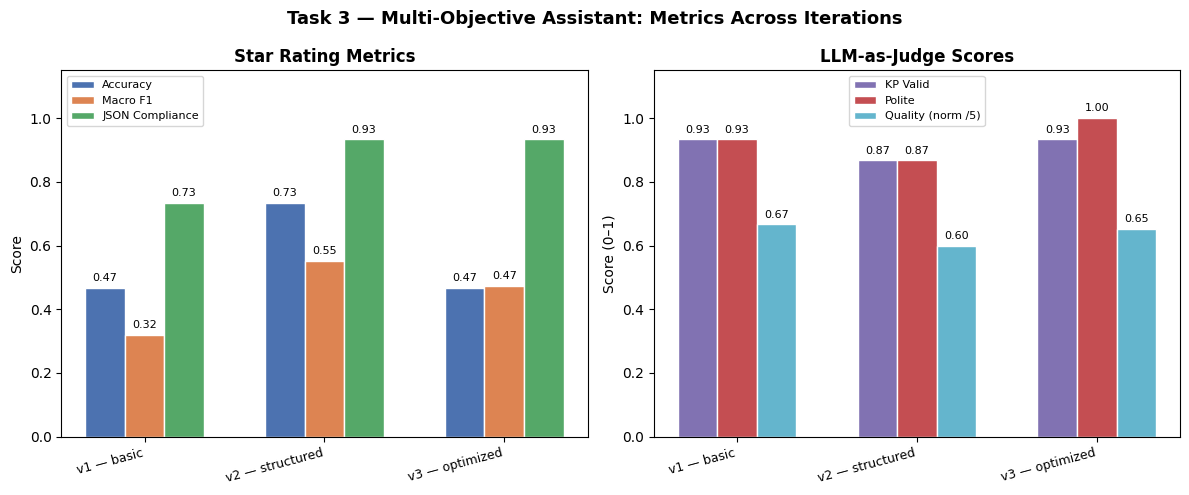

In [18]:
def plot_task3_results():
    """Two-panel chart: star metrics (left) and judge scores (right) per iteration."""
    labels = list(all_iter_results.keys())
    x      = list(range(len(labels)))
    width  = 0.22

    fig, axes = plt.subplots(1, 2, figsize=(max(12, len(labels) * 3.5), 5))

    # ── Left panel: star metrics ─────────────────────────────────────────────
    ax = axes[0]
    metrics_def = [
        ("acc",  "Accuracy",        "#4C72B0"),
        ("f1",   "Macro F1",        "#DD8452"),
        ("json", "JSON Compliance", "#55A868"),
    ]
    for i, (key, name, color) in enumerate(metrics_def):
        vals = []
        for label, ir in all_iter_results.items():
            a, f, fmt = evaluate_basic(ir)
            vals.append({"acc": a, "f1": f, "json": fmt}[key])
        pos  = [j + (i - 1) * width for j in x]
        bars = ax.bar(pos, vals, width, label=name, color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title("Star Rating Metrics", fontsize=12, fontweight="bold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)

    # ── Right panel: judge scores ────────────────────────────────────────────
    ax = axes[1]
    judge_def = [
        ("kp",   "KP Valid",          "#8172B2"),
        ("pol",  "Polite",            "#C44E52"),
        ("qual", "Quality (norm /5)", "#64B5CD"),
    ]
    for i, (key, name, color) in enumerate(judge_def):
        vals = []
        for label in all_iter_results:
            kp, pol, qual = evaluate_judge(all_judge_results.get(label, []))
            raw = {"kp": kp, "pol": pol, "qual": qual / 5}[key]
            vals.append(raw)
        pos  = [j + (i - 1) * width for j in x]
        bars = ax.bar(pos, vals, width, label=name, color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title("LLM-as-Judge Scores", fontsize=12, fontweight="bold")
    ax.set_ylabel("Score (0–1)")
    ax.legend(fontsize=8)

    plt.suptitle("Task 3 — Multi-Objective Assistant: Metrics Across Iterations",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_task3_results()

---

## Key Takeaways

### LLM Judge Is Sensitive to Format

The judge is also a small model producing structured JSON. Simpler field names and numeric values are easier to parse than verbose schemas, which indicates that judge design affects the reliability of the evaluation itself.

### Structured Prompts Improve Stability

Explicit format constraints reduce preamble text and malformed JSON. On Gemma 2B, this suggests that output control is a major part of prompt quality, not just an implementation detail.

### Fallback Ensures Evaluation Robustness

`safe_parse` and `parse_judge` return fallback dictionaries instead of dropping failed rows. This decision was made so every iteration remains comparable, while failed parses still show up in compliance and quality metrics.

### Trade-Off: Correctness vs Reliability

Higher JSON compliance does not guarantee better content. A model can be perfectly parseable and still produce generic responses. This is why star accuracy, key-point validity, politeness, and quality are tracked separately.

### Circular Evaluation Limitation

The same Gemma-2b-it model generates the assistant output and judges it. This likely inflates politeness and compresses quality scores because the model recognises its own boilerplate style. A production evaluation would use a stronger external judge or human labels.


---

## Prompt Iteration Framework

The cells below test different versions of the multi-task prompt without rerunning unrelated setup. This supports controlled iteration: change one prompt, run the same evaluator, and compare all metrics.

**Workflow:**
1. Define a new prompt string, such as `MULTI_TASK_PROMPT_V2`.
2. Call `run_task3_eval(multi_task_prompt=MULTI_TASK_PROMPT_V2, label="v2 - describe the change")`.
3. Repeat for more variants.
4. Call `compare_task3_iterations()` to inspect metric movement.


In [19]:
iteration_log_t3 = []


def run_task3_eval(multi_task_prompt=None, n=None, label="unnamed", save=True):
    """Evaluate the multi-task classifier + judge for one prompt variant."""
    _prompt = multi_task_prompt if multi_task_prompt is not None else MULTI_V3
    _n      = n if n is not None else len(dataset)
    sample  = dataset.select(range(min(_n, len(dataset))))

    _results = []
    for row in sample:
        pred, ok = multi_task_classify(row["text"], _prompt)
        _results.append({
            "true_stars":        row["stars"],
            "pred_stars":        pred["stars"],
            "key_point":         pred.get("key_point", ""),
            "business_response": pred.get("business_response", ""),
            "format_ok":         ok,
            "review":            row["text"],
        })

    acc, f1, fmt = evaluate_basic(_results)

    _judge_list = [
        judge_output(r["review"], r["key_point"], r["business_response"])
        for r in _results
    ]
    kp, pol, qual = evaluate_judge(_judge_list)

    entry = {
        "label":    label,
        "star_acc": acc, "star_f1": f1, "json_fmt": fmt,
        "judged":   f"{len(_judge_list)}/{len(_results)}",
        "kp_valid": kp, "polite": pol, "quality": qual,
    }
    iteration_log_t3.append(entry)

    if save:
        save_results(label, kp, pol, qual)

    print(f"\n[{label}]")
    print(f"  Stars   acc={acc:.3f}  f1={f1:.3f}  json={fmt:.2f}")
    print(f"  Judge   kp={kp:.3f}  polite={pol:.3f}  quality={qual:.3f}  ({entry['judged']} judged)")
    return entry

In [20]:
# Seed iteration_log_t3 from already-computed results (no redundant inference).
for label in all_iter_results:
    kp, pol, qual = evaluate_judge(all_judge_results.get(label, []))
    acc, f1, fmt  = evaluate_basic(all_iter_results[label])
    n_j = len(all_judge_results.get(label, []))
    iteration_log_t3.append({
        "label":    label,
        "star_acc": acc, "star_f1": f1, "json_fmt": fmt,
        "judged":   f"{n_j}/{len(all_iter_results[label])}",
        "kp_valid": kp,  "polite": pol, "quality":  qual,
    })

print(f"Seeded iteration_log_t3 with {len(iteration_log_t3)} entries.")
print("To add a new variant: run_task3_eval(multi_task_prompt=MY_PROMPT, label='v4 — ...')")

Seeded iteration_log_t3 with 3 entries.
To add a new variant: run_task3_eval(multi_task_prompt=MY_PROMPT, label='v4 — ...')


## Comparing Prompt Iterations

The comparison chart separates star-rating metrics from judge metrics. This indicates whether a prompt improves classification, response quality, or only formatting.


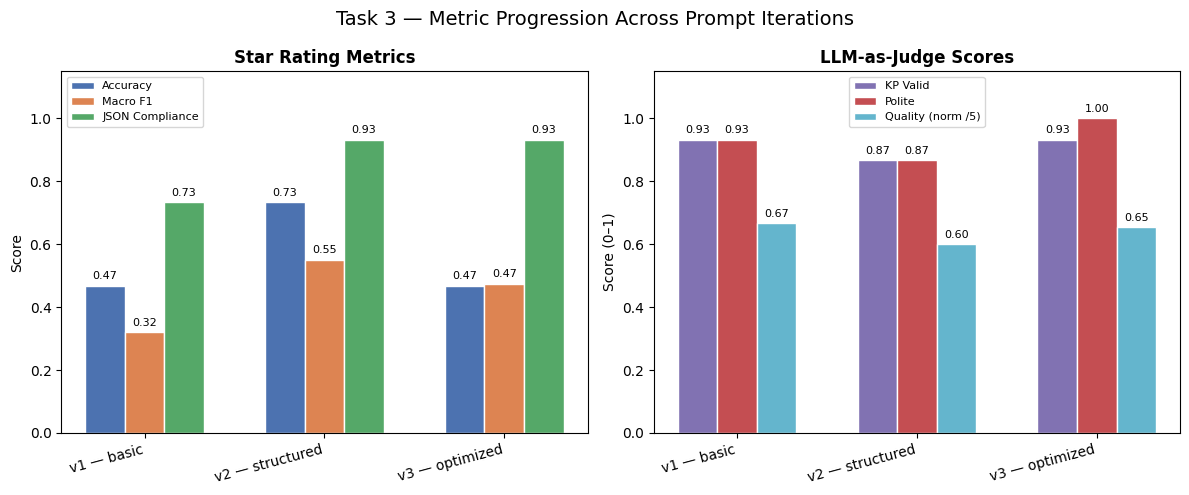

In [21]:
def compare_task3_iterations():
    """Side-by-side panels: star metrics (left) and LLM-judge scores (right) per iteration."""
    if not iteration_log_t3:
        print("No iterations yet — call run_task3_eval() first.")
        return

    labels = [e["label"] for e in iteration_log_t3]
    x      = list(range(len(labels)))
    width  = 0.22

    fig, axes = plt.subplots(1, 2, figsize=(max(12, len(labels) * 3), 5))

    # Left panel — star rating metrics
    ax = axes[0]
    for i, (key, name, color) in enumerate([
        ("star_acc", "Accuracy",       "#4C72B0"),
        ("star_f1",  "Macro F1",       "#DD8452"),
        ("json_fmt", "JSON Compliance","#55A868"),
    ]):
        pos  = [j + (i - 1) * width for j in x]
        vals = [e[key] for e in iteration_log_t3]
        bars = ax.bar(pos, vals, width, label=name, color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylim(0, 1.15); ax.set_title("Star Rating Metrics", fontsize=12, fontweight="bold")
    ax.set_ylabel("Score"); ax.legend(fontsize=8)

    # Right panel — judge scores (quality normalised to 0-1)
    ax = axes[1]
    for i, (key, name, color) in enumerate([
        ("kp_valid", "KP Valid",          "#8172B2"),
        ("polite",   "Polite",            "#C44E52"),
        ("quality",  "Quality (norm /5)", "#64B5CD"),
    ]):
        pos  = [j + (i - 1) * width for j in x]
        vals = [e[key] / 5 if key == "quality" else e[key] for e in iteration_log_t3]
        bars = ax.bar(pos, vals, width, label=name, color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylim(0, 1.15); ax.set_title("LLM-as-Judge Scores", fontsize=12, fontweight="bold")
    ax.set_ylabel("Score (0–1)"); ax.legend(fontsize=8)

    plt.suptitle("Task 3 — Metric Progression Across Prompt Iterations", fontsize=14)
    plt.tight_layout()
    plt.show()


compare_task3_iterations()

---

## Analysis and Conclusion

v2 (structured) produced the strongest overall classification result: 73.3% accuracy and 0.551 macro F1. This suggests that explicit field rules and a 25-word response cap helped the model commit to a specific rating instead of defaulting to the safer middle value of 3.

v3 (optimized) matched v2's JSON compliance at 93.3% and reached 100% politeness, but accuracy dropped to 46.7%. This indicates that extra negation and sarcasm instructions may have added more prompt complexity than Gemma 2B could reliably use. Politeness stayed between 86-100% across versions, and quality stayed in the 3.00-3.33 range, which suggests the self-judge is not very discriminating for this dimension.

The sample outputs show the same pattern. The best examples were fluent and grounded, while the worst example failed both key-point validity and politeness. This indicates that the main bottleneck is not only star prediction; the assistant also needs stronger grounding in the review text.

### What This Task Measures

Task 3 tests whether one prompt can produce a star rating, a grounded key point, and a polite business response. The LLM-as-judge adds a second lens by asking whether the generated content is useful, not just parseable.

### Suggested Next Iterations

1. Require the business response to directly address the extracted key point.
2. Shorten field names to reduce token pressure.
3. Split the workflow into rating/key-point extraction and response generation, then compare against the single-prompt design.
